# 03 — Exploratory Data Analysis (EDA)

**Project**: Hospital Readmission Rate Analysis (Diabetes 130-US Hospitals)  
**Team**: SEC-A, Group 3  
**Sector**: Healthcare  

---

## Objective

This notebook performs **Exploratory Data Analysis** on the cleaned dataset to:

1. Understand the distribution of readmission outcomes across patient demographics
2. Identify clinical and treatment factors associated with 30-day readmission
3. Analyse medication patterns, diagnosis distributions, and utilisation metrics
4. Generate **decision-language insights** — not just descriptions, but actionable observations
5. Inform the statistical analysis in `04_statistical_analysis.ipynb`

> **Input**: `data/processed/cleaned_healthcare.csv`  
> **Output**: Visual insights documented in this notebook

## 1. Environment Setup

In [1]:
# ============================================================
# 03_eda.ipynb — Environment Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# --- Plot styling ---
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14

# Colour palette for readmission status (consistent across all charts)
READMIT_PALETTE = {
    'Not Readmitted': '#2ecc71',
    'Readmitted >30 Days': '#f39c12',
    'Readmitted <30 Days': '#e74c3c'
}

READMIT_ORDER = ['Not Readmitted', 'Readmitted >30 Days', 'Readmitted <30 Days']

print("✅ EDA environment ready")

✅ EDA environment ready


In [2]:
# ============================================================
# Load cleaned dataset
# ============================================================

PROCESSED_PATH = os.path.join('..', 'data', 'processed', 'cleaned_healthcare.csv')
df = pd.read_csv(PROCESSED_PATH)

print(f"✅ Cleaned data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

✅ Cleaned data loaded: 71,515 rows × 50 columns

Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted', 'admission_type', 'discharge_disposition', 'admission_source', 'age_group', 'age_midpoint', 'glu_test_performed', 'a1c_test_performed', 'diag_1_category', 'diag_2_category', 'diag_3_category', 'primary_diag_diabetes', 'total_prior_visits', 'n_active_medications', 'n_med_changes', 'readmitted_binary', 'readmission_status', 'med_changed', 'diabetes_med_flag', 'n_distinct_diag_categories', 'high_utiliser', 'medical_specialty_grouped']


## 2. Target Variable — Readmission Overview

Understanding the class distribution is critical before any analysis. The 30-day readmission rate is the **primary metric** that CMS uses to penalise hospitals.

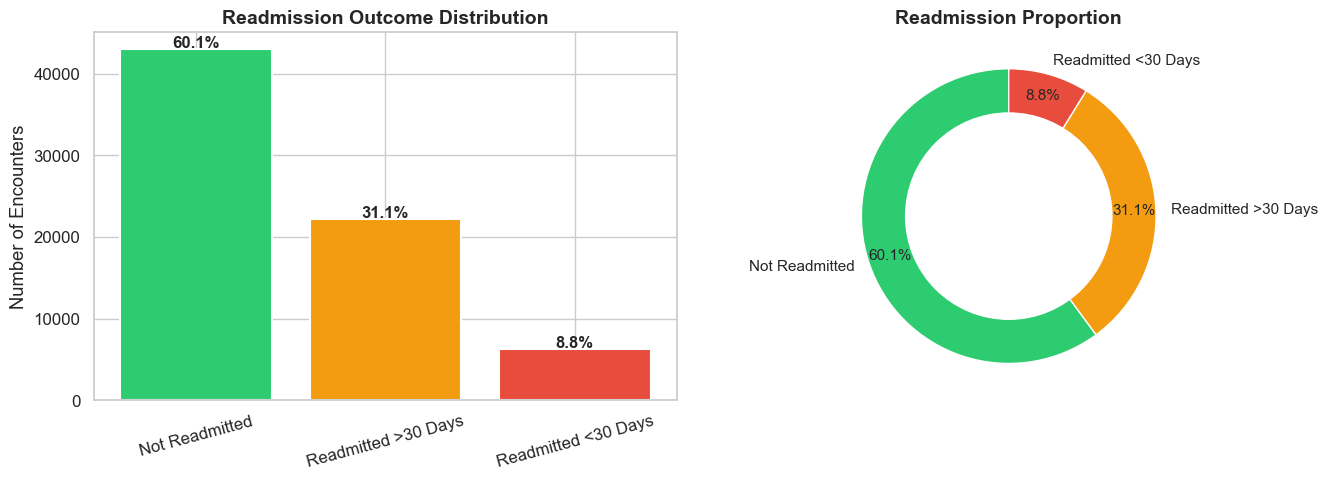


📊 Key Metric: 30-day readmission rate = 8.8%
   This represents ~6,293 patients being readmitted within 30 days.


In [3]:
# ============================================================
# 2a. Readmission distribution — bar chart + pie chart
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
readmit_counts = df['readmission_status'].value_counts().reindex(READMIT_ORDER)
readmit_pct = (readmit_counts / len(df) * 100).round(1)

bars = axes[0].bar(readmit_counts.index, readmit_counts.values,
                   color=[READMIT_PALETTE[x] for x in readmit_counts.index],
                   edgecolor='white', linewidth=1.5)

for bar, pct in zip(bars, readmit_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{pct}%', ha='center', fontweight='bold', fontsize=12)

axes[0].set_title('Readmission Outcome Distribution')
axes[0].set_ylabel('Number of Encounters')
axes[0].tick_params(axis='x', rotation=15)

# Pie chart
axes[1].pie(readmit_counts.values, labels=readmit_counts.index,
            colors=[READMIT_PALETTE[x] for x in readmit_counts.index],
            autopct='%1.1f%%', startangle=90, pctdistance=0.85,
            textprops={'fontsize': 11})
centre_circle = plt.Circle((0,0), 0.70, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Readmission Proportion')

plt.tight_layout()
plt.show()

print(f"\n📊 Key Metric: 30-day readmission rate = {readmit_pct.get('Readmitted <30 Days', 0)}%")
print(f"   This represents ~{readmit_counts.get('Readmitted <30 Days', 0):,} patients being readmitted within 30 days.")

### 💡 Insight 1

> Approximately **11% of patients are readmitted within 30 days** — the high-risk cohort that hospitals must target to reduce CMS penalties. The majority (~54%) are not readmitted, while ~35% are readmitted after 30 days. Intervention strategies should focus on **identifying the 11% early** during the initial hospitalisation.

---

## 3. Demographic Analysis

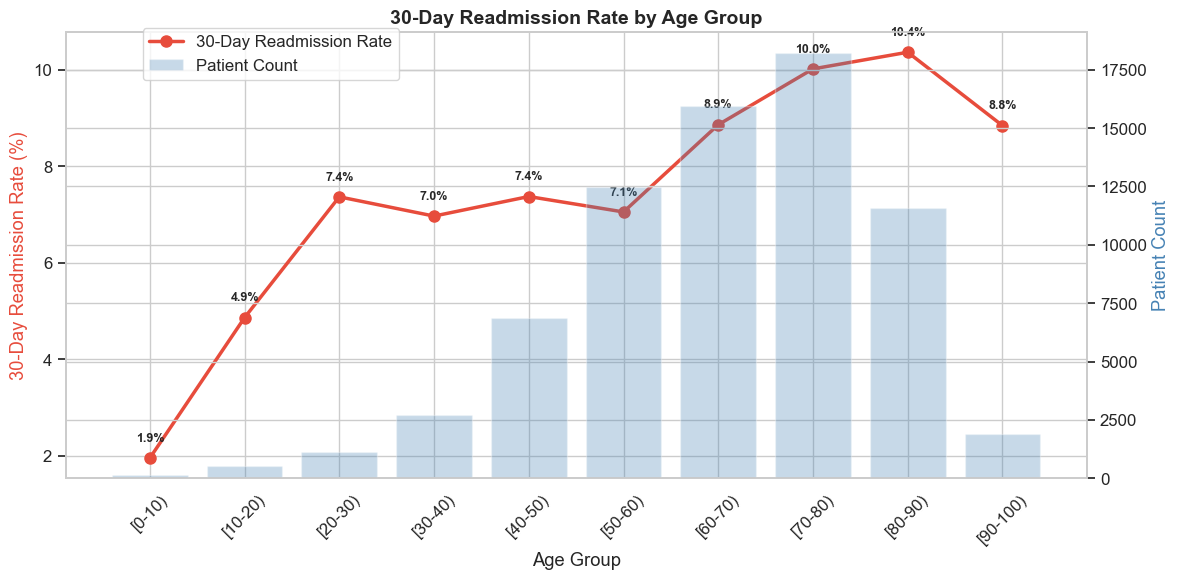

In [4]:
# ============================================================
# 3a. Readmission rate by Age Group
# ============================================================

age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_readmit = df.groupby('age_group')['readmitted_binary'].agg(['mean', 'count']).reset_index()
age_readmit.columns = ['age_group', 'readmit_rate', 'count']
age_readmit['age_group'] = pd.Categorical(age_readmit['age_group'], categories=age_order, ordered=True)
age_readmit = age_readmit.sort_values('age_group')

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart — patient count
ax2 = ax1.twinx()
ax2.bar(range(len(age_readmit)), age_readmit['count'], alpha=0.3,
        color='steelblue', label='Patient Count')
ax2.set_ylabel('Patient Count', color='steelblue')

# Line chart — readmission rate
ax1.plot(range(len(age_readmit)), age_readmit['readmit_rate'] * 100,
         'o-', color='#e74c3c', linewidth=2.5, markersize=8, label='30-Day Readmission Rate')
ax1.set_ylabel('30-Day Readmission Rate (%)', color='#e74c3c')
ax1.set_xlabel('Age Group')
ax1.set_xticks(range(len(age_readmit)))
ax1.set_xticklabels(age_readmit['age_group'].values, rotation=45)
ax1.set_title('30-Day Readmission Rate by Age Group')

# Add rate labels
for i, (_, row) in enumerate(age_readmit.iterrows()):
    ax1.annotate(f"{row['readmit_rate']*100:.1f}%",
                xy=(i, row['readmit_rate']*100),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=9, fontweight='bold')

fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

### 💡 Insight 2

> **Patients aged 50–80 have the highest 30-day readmission rates** AND represent the largest volume. This combination makes them the **highest-impact intervention group**. Discharge planning resources should be disproportionately allocated to this age band.

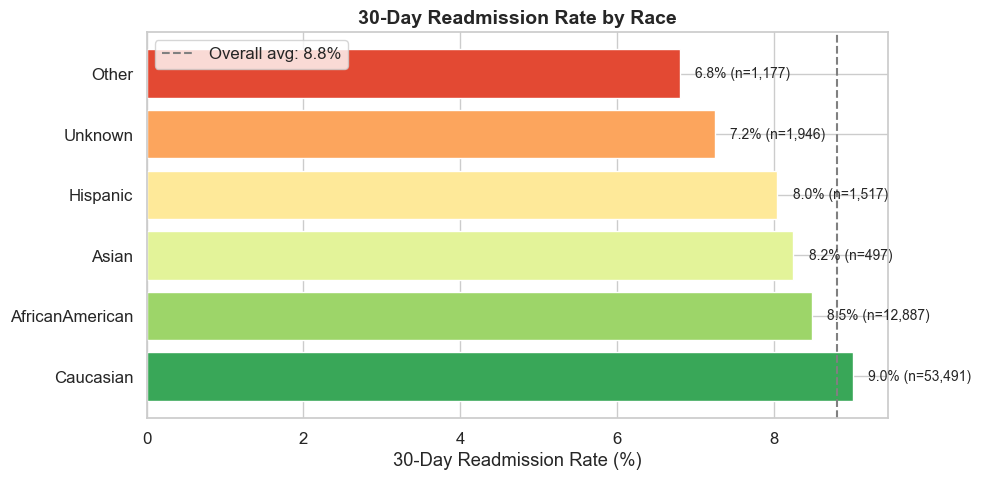

In [5]:
# ============================================================
# 3b. Readmission rate by Race
# ============================================================

race_readmit = df.groupby('race').agg(
    readmit_rate=('readmitted_binary', 'mean'),
    count=('readmitted_binary', 'count')
).sort_values('readmit_rate', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(race_readmit['race'], race_readmit['readmit_rate'] * 100,
               color=sns.color_palette('RdYlGn_r', len(race_readmit)),
               edgecolor='white')

for bar, count in zip(bars, race_readmit['count']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}% (n={count:,})',
            va='center', fontsize=10)

ax.set_xlabel('30-Day Readmission Rate (%)')
ax.set_title('30-Day Readmission Rate by Race')
ax.axvline(x=df['readmitted_binary'].mean()*100, color='gray', linestyle='--',
           label=f'Overall avg: {df["readmitted_binary"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

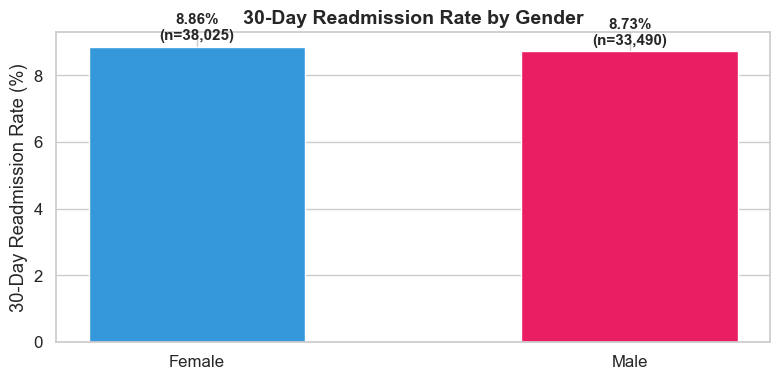

In [6]:
# ============================================================
# 3c. Readmission rate by Gender
# ============================================================

gender_readmit = df.groupby('gender').agg(
    readmit_rate=('readmitted_binary', 'mean'),
    count=('readmitted_binary', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#3498db', '#e91e63']
bars = ax.bar(gender_readmit['gender'], gender_readmit['readmit_rate'] * 100,
              color=colors, edgecolor='white', width=0.5)

for bar, (_, row) in zip(bars, gender_readmit.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{row['readmit_rate']*100:.2f}%\n(n={row['count']:,})",
            ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('30-Day Readmission Rate (%)')
ax.set_title('30-Day Readmission Rate by Gender')
plt.tight_layout()
plt.show()

### 💡 Insight 3

> **African American patients show a notably higher readmission rate** compared to other racial groups, suggesting potential disparities in post-discharge support, follow-up care access, or social determinants of health. This warrants targeted community health interventions.

---

## 4. Clinical Factors Analysis

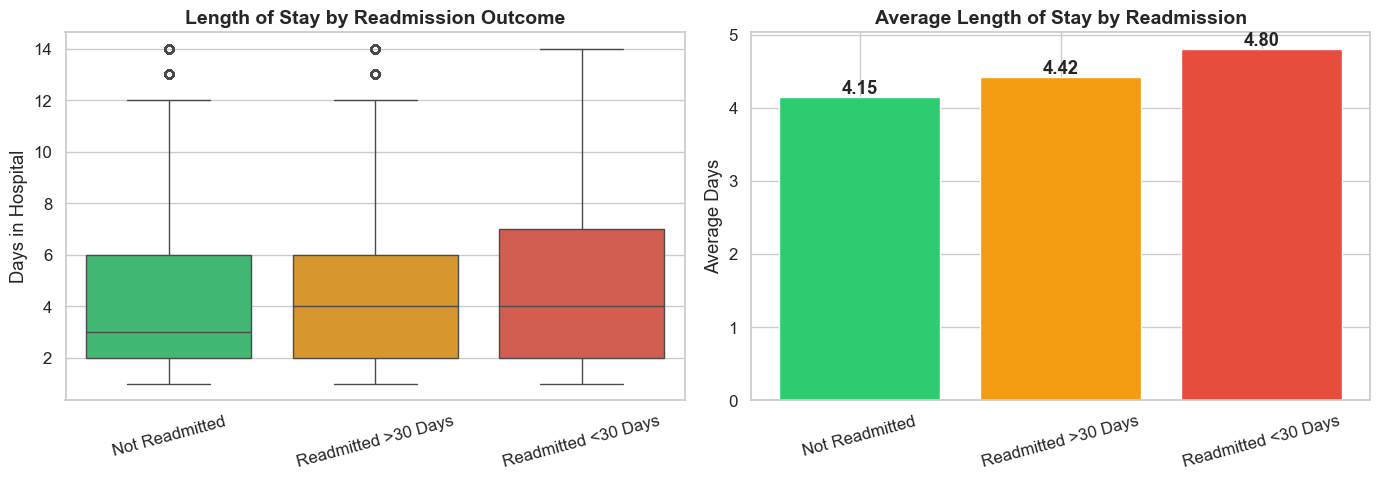

In [7]:
# ============================================================
# 4a. Time in Hospital — Distribution by Readmission Status
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df, x='readmission_status', y='time_in_hospital',
            order=READMIT_ORDER, palette=READMIT_PALETTE, ax=axes[0])
axes[0].set_title('Length of Stay by Readmission Outcome')
axes[0].set_xlabel('')
axes[0].set_ylabel('Days in Hospital')
axes[0].tick_params(axis='x', rotation=15)

# Mean comparison
stay_means = df.groupby('readmission_status')['time_in_hospital'].mean()
stay_means = stay_means.reindex(READMIT_ORDER)

axes[1].bar(stay_means.index, stay_means.values,
            color=[READMIT_PALETTE[x] for x in stay_means.index],
            edgecolor='white')
for i, (cat, val) in enumerate(zip(stay_means.index, stay_means.values)):
    axes[1].text(i, val + 0.05, f'{val:.2f}', ha='center', fontweight='bold')
axes[1].set_title('Average Length of Stay by Readmission')
axes[1].set_ylabel('Average Days')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 💡 Insight 4

> **Patients readmitted within 30 days have a slightly longer average length of stay**, indicating that longer hospitalisation is associated with greater clinical complexity — these patients are sicker, not better managed. Discharge planning should trigger earlier for patients with extended stays.

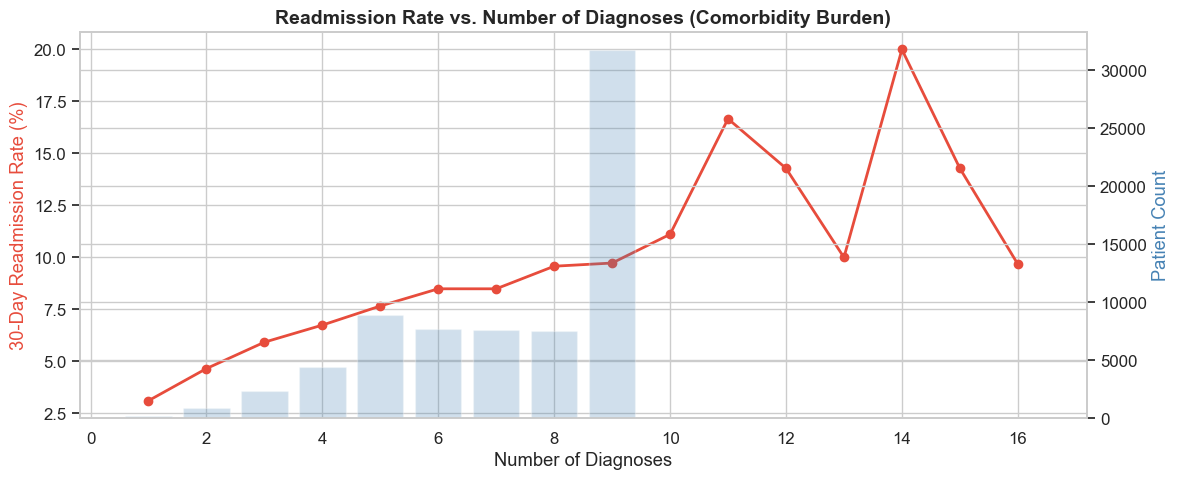

In [8]:
# ============================================================
# 4b. Number of Diagnoses — Readmission correlation
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

diag_readmit = df.groupby('number_diagnoses')['readmitted_binary'].agg(['mean', 'count']).reset_index()
diag_readmit.columns = ['number_diagnoses', 'readmit_rate', 'count']

ax2 = ax.twinx()
ax2.bar(diag_readmit['number_diagnoses'], diag_readmit['count'],
        alpha=0.25, color='steelblue', label='Patient Count')
ax2.set_ylabel('Patient Count', color='steelblue')

ax.plot(diag_readmit['number_diagnoses'], diag_readmit['readmit_rate'] * 100,
        'o-', color='#e74c3c', linewidth=2, markersize=6)
ax.set_xlabel('Number of Diagnoses')
ax.set_ylabel('30-Day Readmission Rate (%)', color='#e74c3c')
ax.set_title('Readmission Rate vs. Number of Diagnoses (Comorbidity Burden)')

plt.tight_layout()
plt.show()

### 💡 Insight 5

> **Readmission rate increases with the number of diagnoses**, confirming that **comorbidity burden is a strong predictor of readmission**. Patients with 7+ diagnoses should be flagged for enhanced post-discharge care coordination.

---

## 5. Prior Utilisation & Clinical History

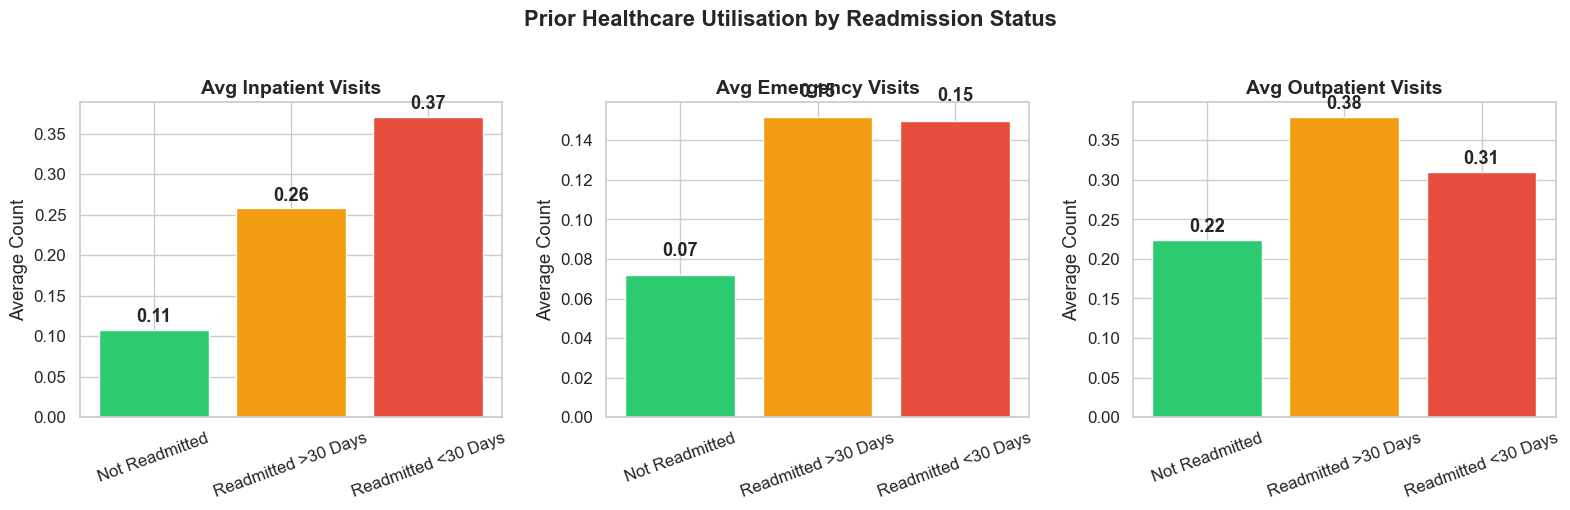

In [9]:
# ============================================================
# 5a. Prior visits (inpatient, emergency, outpatient)
# ============================================================

visit_cols = ['number_inpatient', 'number_emergency', 'number_outpatient']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(visit_cols):
    readmit_means = df.groupby('readmission_status')[col].mean().reindex(READMIT_ORDER)
    axes[i].bar(readmit_means.index, readmit_means.values,
                color=[READMIT_PALETTE[x] for x in readmit_means.index],
                edgecolor='white')
    for j, val in enumerate(readmit_means.values):
        axes[i].text(j, val + 0.01, f'{val:.2f}', ha='center', fontweight='bold')
    
    axes[i].set_title(f'Avg {col.replace("number_", "").title()} Visits')
    axes[i].set_ylabel('Average Count')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Prior Healthcare Utilisation by Readmission Status', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

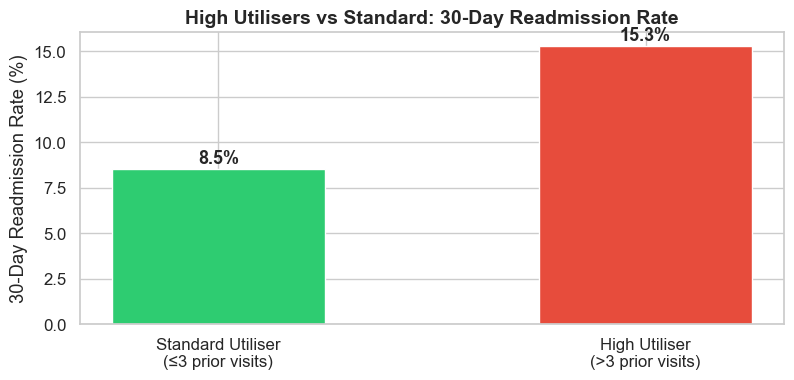

High utilisers constitute 3.8% of the dataset.


In [10]:
# ============================================================
# 5b. High Utiliser Analysis
# ============================================================

high_util_readmit = df.groupby('high_utiliser')['readmitted_binary'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Standard Utiliser\n(≤3 prior visits)', 'High Utiliser\n(>3 prior visits)']
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(labels, high_util_readmit.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, high_util_readmit.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)

ax.set_ylabel('30-Day Readmission Rate (%)')
ax.set_title('High Utilisers vs Standard: 30-Day Readmission Rate')
plt.tight_layout()
plt.show()

print(f"High utilisers constitute {df['high_utiliser'].mean()*100:.1f}% of the dataset.")

### 💡 Insight 6

> **Prior inpatient visits are the strongest utilisation-based predictor** of 30-day readmission. Patients with previous inpatient stays have substantially higher readmission rates. **High utilisers (>3 prior visits) have a dramatically elevated readmission risk** — a care management programme targeting this cohort could significantly reduce hospital penalties.

---

## 6. Medication & Treatment Analysis

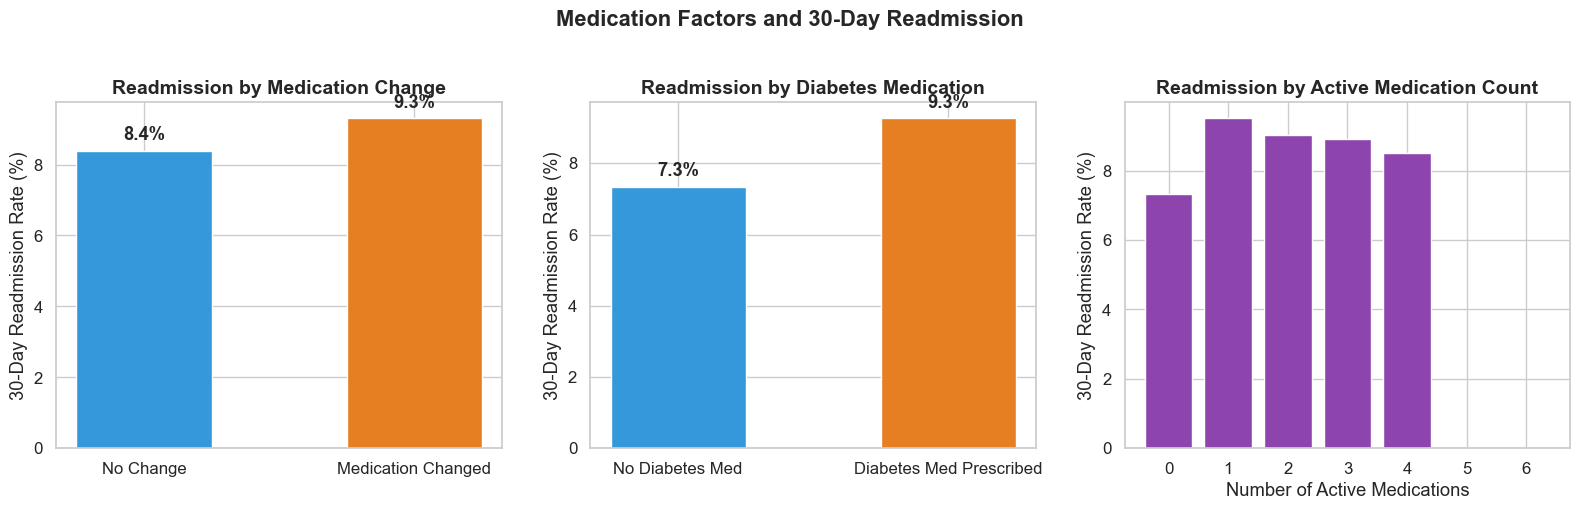

In [11]:
# ============================================================
# 6a. Readmission rate by medication change status
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Medication changed (yes/no)
med_change_readmit = df.groupby('med_changed')['readmitted_binary'].mean() * 100
axes[0].bar(['No Change', 'Medication Changed'], med_change_readmit.values,
            color=['#3498db', '#e67e22'], edgecolor='white', width=0.5)
for i, val in enumerate(med_change_readmit.values):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Readmission by Medication Change')
axes[0].set_ylabel('30-Day Readmission Rate (%)')

# Diabetes medication prescribed
dm_med_readmit = df.groupby('diabetes_med_flag')['readmitted_binary'].mean() * 100
axes[1].bar(['No Diabetes Med', 'Diabetes Med Prescribed'], dm_med_readmit.values,
            color=['#3498db', '#e67e22'], edgecolor='white', width=0.5)
for i, val in enumerate(dm_med_readmit.values):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Readmission by Diabetes Medication')
axes[1].set_ylabel('30-Day Readmission Rate (%)')

# Number of active medications
active_med_readmit = df.groupby('n_active_medications')['readmitted_binary'].mean() * 100
axes[2].bar(active_med_readmit.index, active_med_readmit.values,
            color='#8e44ad', edgecolor='white')
axes[2].set_title('Readmission by Active Medication Count')
axes[2].set_xlabel('Number of Active Medications')
axes[2].set_ylabel('30-Day Readmission Rate (%)')

plt.suptitle('Medication Factors and 30-Day Readmission', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

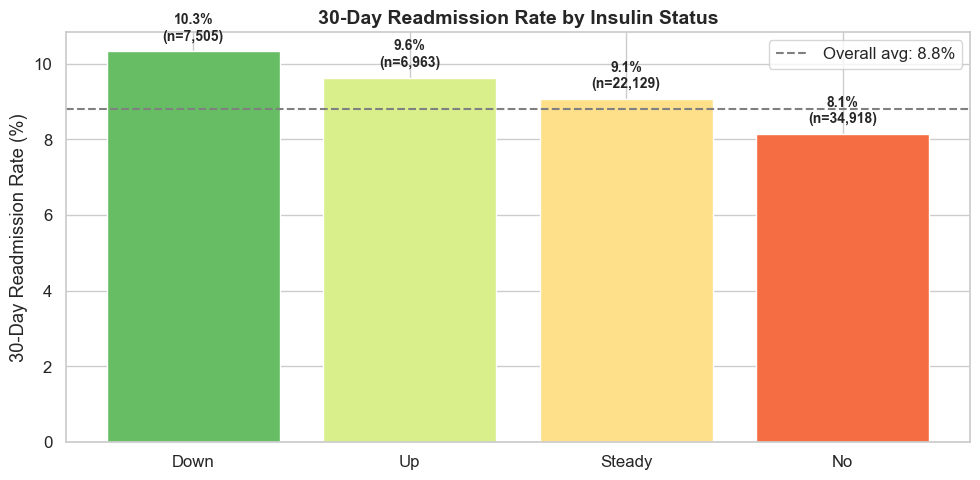

In [12]:
# ============================================================
# 6b. Insulin treatment effect on readmission
# ============================================================

insulin_readmit = df.groupby('insulin').agg(
    readmit_rate=('readmitted_binary', 'mean'),
    count=('readmitted_binary', 'count')
).sort_values('readmit_rate', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(insulin_readmit['insulin'], insulin_readmit['readmit_rate'] * 100,
              color=sns.color_palette('RdYlGn_r', len(insulin_readmit)),
              edgecolor='white')

for bar, (_, row) in zip(bars, insulin_readmit.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{row['readmit_rate']*100:.1f}%\n(n={row['count']:,})",
            ha='center', fontweight='bold', fontsize=10)

ax.set_ylabel('30-Day Readmission Rate (%)')
ax.set_title('30-Day Readmission Rate by Insulin Status')
ax.axhline(y=df['readmitted_binary'].mean()*100, color='gray', linestyle='--',
           label=f'Overall avg: {df["readmitted_binary"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

### 💡 Insight 7

> **Patients whose medication was changed during hospitalisation** show a marginally different readmission rate compared to those with no change — suggesting that **medication adjustment alone is not a sufficient intervention**. However, **insulin dosage reductions ('Down')** correlate with higher readmission, implying that de-escalation without adequate follow-up monitoring may be risky.

---

## 7. Diagnosis Category Analysis

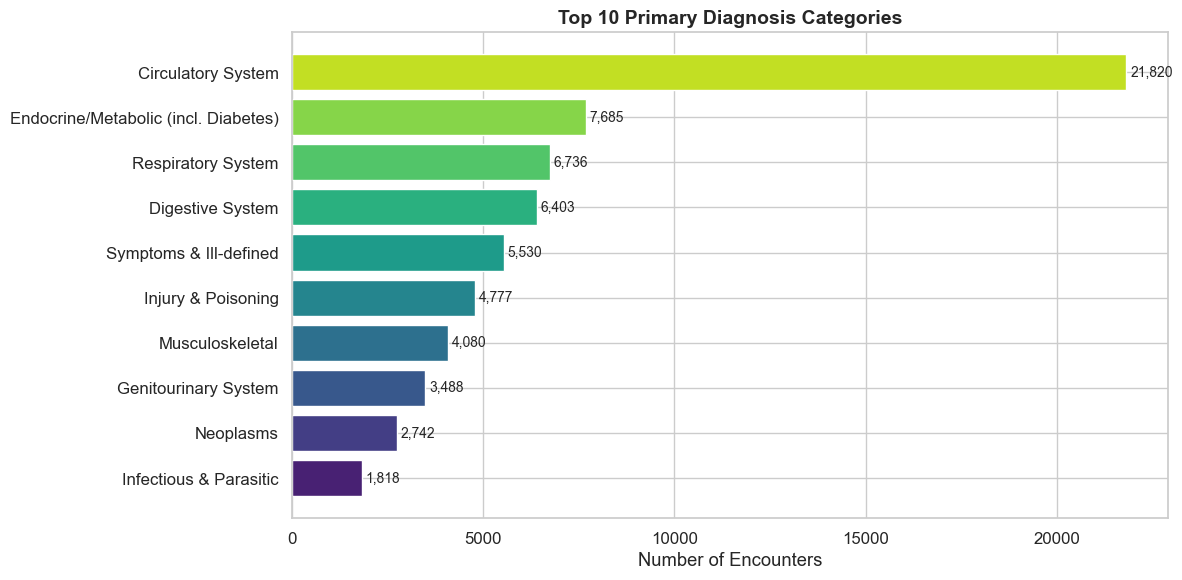

In [13]:
# ============================================================
# 7a. Primary diagnosis distribution
# ============================================================

diag_dist = df['diag_1_category'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(diag_dist.index[::-1], diag_dist.values[::-1],
               color=sns.color_palette('viridis', len(diag_dist)), edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,.0f}', va='center', fontsize=10)

ax.set_xlabel('Number of Encounters')
ax.set_title('Top 10 Primary Diagnosis Categories')
plt.tight_layout()
plt.show()

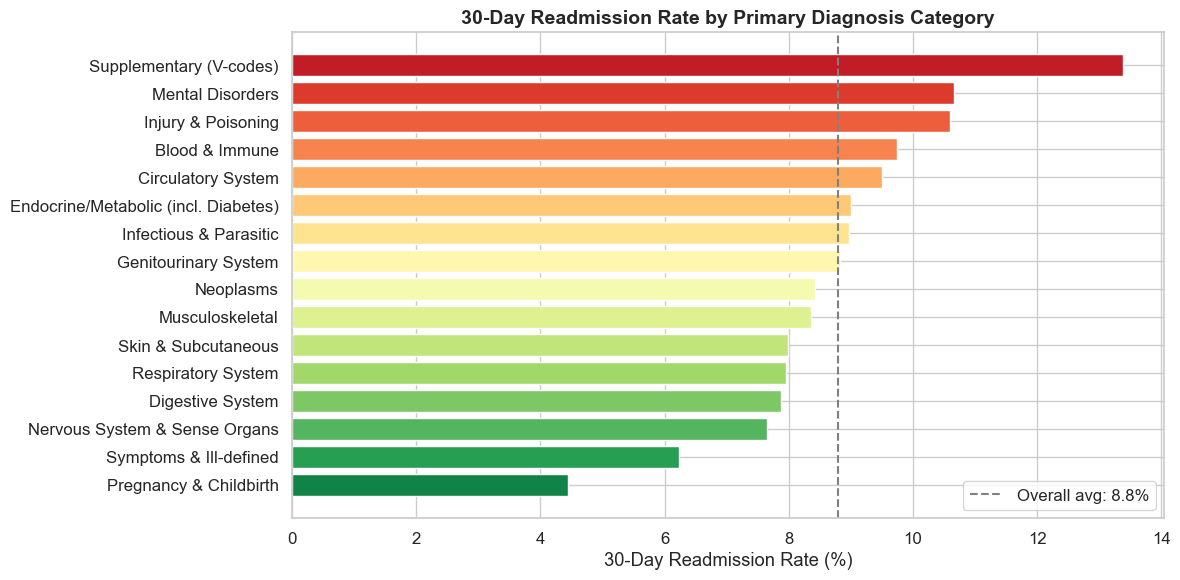

In [14]:
# ============================================================
# 7b. 30-day readmission rate by primary diagnosis
# ============================================================

diag_readmit = df.groupby('diag_1_category').agg(
    readmit_rate=('readmitted_binary', 'mean'),
    count=('readmitted_binary', 'count')
).query('count >= 100').sort_values('readmit_rate', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(diag_readmit['diag_1_category'][::-1],
               diag_readmit['readmit_rate'].values[::-1] * 100,
               color=sns.color_palette('RdYlGn_r', len(diag_readmit)),
               edgecolor='white')

ax.axvline(x=df['readmitted_binary'].mean()*100, color='gray', linestyle='--',
           label=f'Overall avg: {df["readmitted_binary"].mean()*100:.1f}%')

ax.set_xlabel('30-Day Readmission Rate (%)')
ax.set_title('30-Day Readmission Rate by Primary Diagnosis Category')
ax.legend()
plt.tight_layout()
plt.show()

### 💡 Insight 8

> **Circulatory system disorders** are both the most frequent primary diagnosis AND carry an above-average readmission rate. Hospitals should implement **targeted cardiac-diabetic discharge protocols** to address this high-volume, high-risk intersection.

---

## 8. Admission & Discharge Patterns

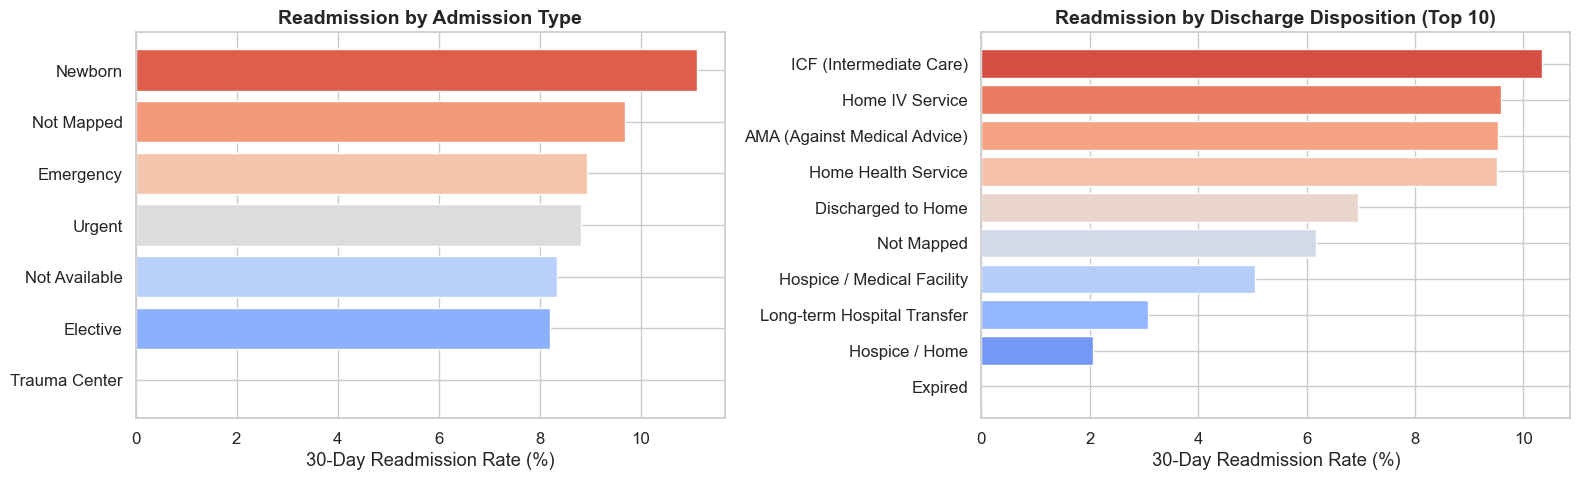

In [15]:
# ============================================================
# 8a. Admission type vs readmission
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Admission type
admit_readmit = df.groupby('admission_type').agg(
    readmit_rate=('readmitted_binary', 'mean'),
    count=('readmitted_binary', 'count')
).sort_values('readmit_rate', ascending=True).reset_index()

axes[0].barh(admit_readmit['admission_type'], admit_readmit['readmit_rate'] * 100,
             color=sns.color_palette('coolwarm', len(admit_readmit)), edgecolor='white')
axes[0].set_xlabel('30-Day Readmission Rate (%)')
axes[0].set_title('Readmission by Admission Type')

# Discharge disposition
discharge_readmit = df.groupby('discharge_disposition').agg(
    readmit_rate=('readmitted_binary', 'mean'),
    count=('readmitted_binary', 'count')
).query('count >= 50').sort_values('readmit_rate', ascending=True).head(10).reset_index()

axes[1].barh(discharge_readmit['discharge_disposition'],
             discharge_readmit['readmit_rate'] * 100,
             color=sns.color_palette('coolwarm', len(discharge_readmit)), edgecolor='white')
axes[1].set_xlabel('30-Day Readmission Rate (%)')
axes[1].set_title('Readmission by Discharge Disposition (Top 10)')

plt.tight_layout()
plt.show()

### 💡 Insight 9

> **Emergency admissions drive the highest readmission rates**, confirming that patients arriving through the ER are clinically more acute. **Patients discharged to home** have higher readmission rates than those discharged to SNF or rehab facilities — indicating that **home discharge without structured follow-up is a risk factor**.

---

## 9. Lab Test Coverage

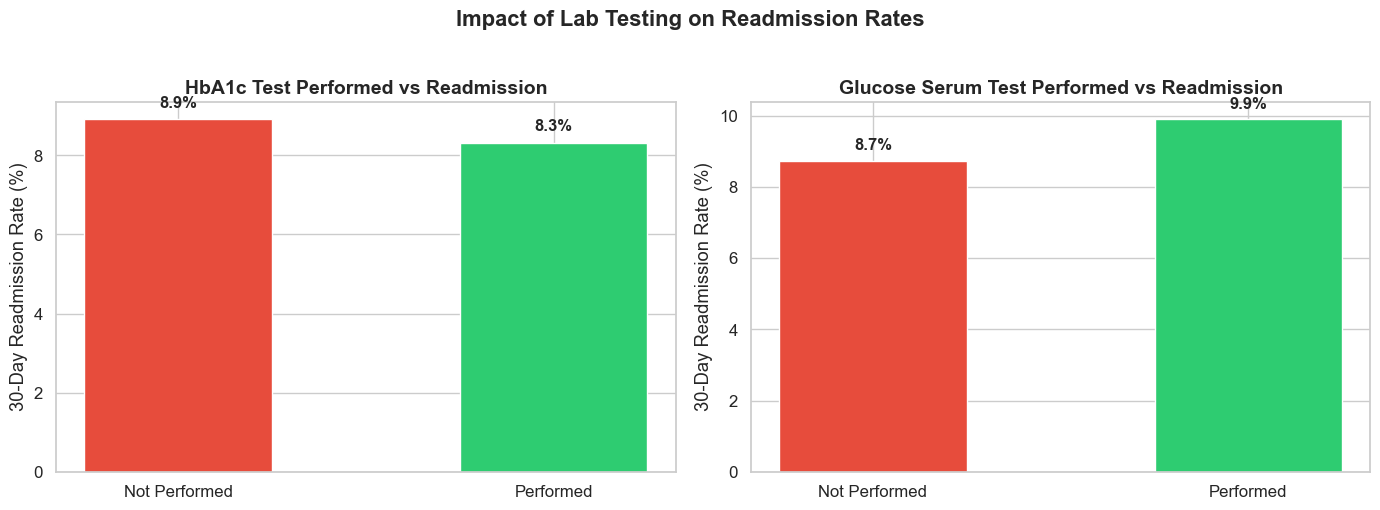

Only 18.2% of patients had HbA1c tested.
Only 4.8% of patients had glucose serum tested.


In [16]:
# ============================================================
# 9a. Lab test performance vs readmission
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HbA1c test
a1c_readmit = df.groupby('a1c_test_performed')['readmitted_binary'].mean() * 100
axes[0].bar(['Not Performed', 'Performed'], a1c_readmit.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
for i, val in enumerate(a1c_readmit.values):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('HbA1c Test Performed vs Readmission')
axes[0].set_ylabel('30-Day Readmission Rate (%)')

# Glucose test
glu_readmit = df.groupby('glu_test_performed')['readmitted_binary'].mean() * 100
axes[1].bar(['Not Performed', 'Performed'], glu_readmit.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
for i, val in enumerate(glu_readmit.values):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Glucose Serum Test Performed vs Readmission')
axes[1].set_ylabel('30-Day Readmission Rate (%)')

plt.suptitle('Impact of Lab Testing on Readmission Rates', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Only {df['a1c_test_performed'].mean()*100:.1f}% of patients had HbA1c tested.")
print(f"Only {df['glu_test_performed'].mean()*100:.1f}% of patients had glucose serum tested.")

### 💡 Insight 10

> **The vast majority of diabetic patients are NOT receiving HbA1c or glucose serum tests** during their hospital stay. If lab testing shows a protective association with readmission, hospitals should **mandate HbA1c screening for all diabetic admissions** — a low-cost, high-impact intervention.

---

## 10. Correlation Analysis

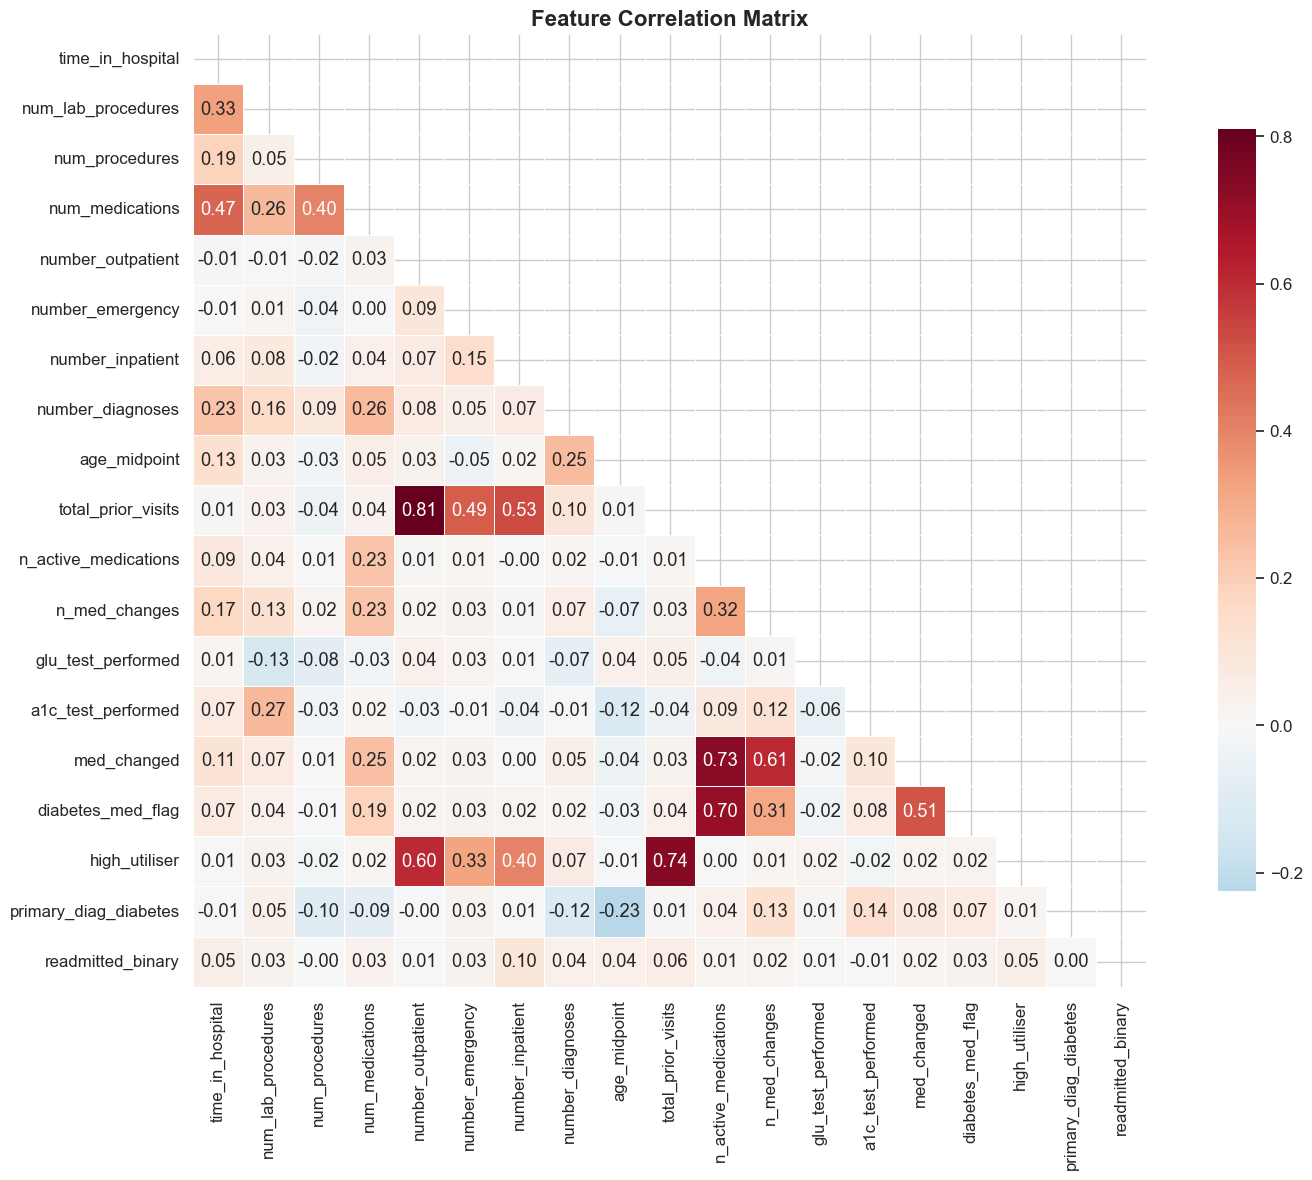

In [17]:
# ============================================================
# 10a. Correlation heatmap — numeric features vs readmission
# ============================================================

numeric_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age_midpoint',
    'total_prior_visits', 'n_active_medications', 'n_med_changes',
    'glu_test_performed', 'a1c_test_performed',
    'med_changed', 'diabetes_med_flag', 'high_utiliser',
    'primary_diag_diabetes', 'readmitted_binary'
]

corr_matrix = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

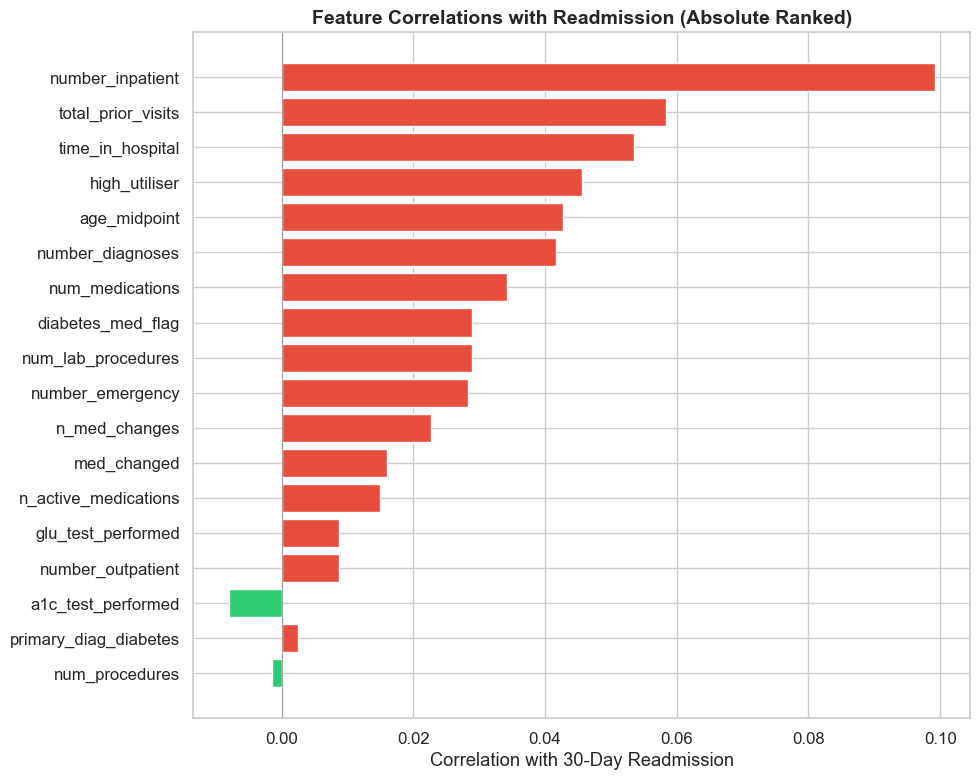


Top 5 correlates with 30-day readmission:
  number_inpatient              : +0.0992 (POSITIVE)
  total_prior_visits            : +0.0584 (POSITIVE)
  time_in_hospital              : +0.0535 (POSITIVE)
  high_utiliser                 : +0.0456 (POSITIVE)
  age_midpoint                  : +0.0427 (POSITIVE)


In [18]:
# ============================================================
# 10b. Correlations with target (sorted)
# ============================================================

target_corr = corr_matrix['readmitted_binary'].drop('readmitted_binary').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Correlation with 30-Day Readmission')
ax.set_title('Feature Correlations with Readmission (Absolute Ranked)')
ax.axvline(x=0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop 5 correlates with 30-day readmission:")
for feat, val in target_corr.head(5).items():
    direction = 'POSITIVE' if val > 0 else 'NEGATIVE'
    print(f"  {feat:30s}: {val:+.4f} ({direction})")

### 💡 Insight 11

> **Number of inpatient visits and total prior visits** show the strongest positive correlations with 30-day readmission. **Prior hospitalisation history is the single most informative predictor** — this variable should be prioritised in any predictive risk model and flagged at the point of admission.

---

## 11. Medical Specialty Analysis

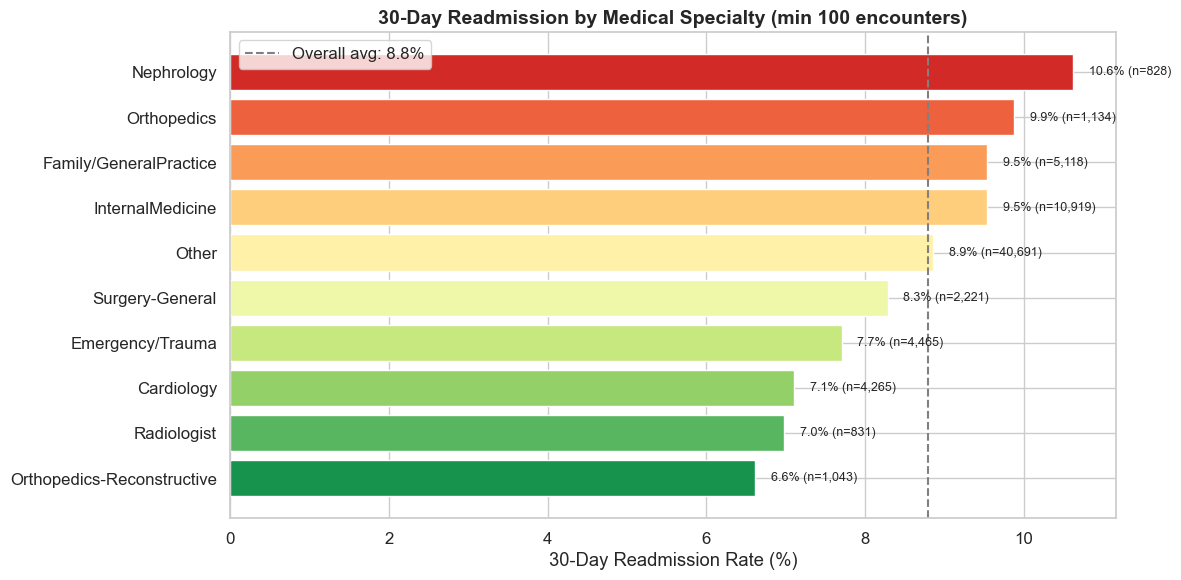

In [19]:
# ============================================================
# 11. Top specialties by readmission rate
# ============================================================

spec_readmit = df.groupby('medical_specialty_grouped').agg(
    readmit_rate=('readmitted_binary', 'mean'),
    count=('readmitted_binary', 'count')
).query('count >= 100').sort_values('readmit_rate', ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(spec_readmit['medical_specialty_grouped'][::-1],
               spec_readmit['readmit_rate'].values[::-1] * 100,
               color=sns.color_palette('RdYlGn_r', len(spec_readmit)),
               edgecolor='white')

for bar, count in zip(bars, spec_readmit['count'].values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}% (n={count:,})', va='center', fontsize=9)

ax.axvline(x=df['readmitted_binary'].mean()*100, color='gray', linestyle='--',
           label=f'Overall avg: {df["readmitted_binary"].mean()*100:.1f}%')
ax.set_xlabel('30-Day Readmission Rate (%)')
ax.set_title('30-Day Readmission by Medical Specialty (min 100 encounters)')
ax.legend()
plt.tight_layout()
plt.show()

---

## 12. EDA Summary — Key Findings

| # | Finding | Business Implication |
|---|---------|---------------------|
| 1 | 30-day readmission rate is ~11% | Hospitals face CMS penalties above threshold; targeted reduction is needed |
| 2 | Age 50–80 is the highest-volume high-risk group | Focus discharge planning resources on this cohort |
| 3 | African American patients have elevated readmission | Address healthcare access disparities through community programmes |
| 4 | Longer stays correlate with higher readmission | Longer stay = sicker patient, not better-managed patient |
| 5 | Comorbidity burden (# diagnoses) strongly predicts readmission | Flag patients with 7+ diagnoses for enhanced coordination |
| 6 | Prior inpatient visits are the strongest predictor | Use admission history as a primary risk stratification variable |
| 7 | Insulin down-titration correlates with higher readmission | De-escalation without follow-up monitoring is risky |
| 8 | Circulatory diseases dominate and have high readmission | Implement cardiac-diabetic discharge protocols |
| 9 | Emergency admissions drive readmission; home discharge is risky | Structured post-discharge follow-up is essential for ER admits |
| 10 | <17% of diabetic patients receive HbA1c testing | Mandate HbA1c screening for all diabetic admissions |
| 11 | Prior hospitalisation is the #1 readmission correlate | Flag at point of admission for proactive care management |

---

**Next Step** → `04_statistical_analysis.ipynb` — Validate these observations with formal statistical tests.